In [2]:
%%writefile scripts/codeAgent.py
class LLMCodeAgent:
    def __init__(self, modulePath:str):
        pass
    def __iter__(self):
        self.a = 1
        self.status = "error"
        return self
    def __next__(self):
        confirm = input(f"Next? (y/n) ")
        if confirm == "n" or confirm == "N":
            print("End Agent")
            raise StopIteration

        x = self.a
        self.a += 1
        return (x, self.status)

    def __call__(self):
        print("Start agent")
        myiter = iter(self)
        currentStatus = None
        for x in myiter:
            currentStatus = x
            print("iter status", currentStatus[1], ". iter times: ", currentStatus[0])

        print("last status", currentStatus[1], ". iter times: ", currentStatus[0])


Overwriting scripts/codeAgent.py


In [ ]:
import os
os._exit(00)

In [5]:
%run scripts/codeAgent.py

In [1]:
from scripts.codeAgent import LLMCodeAgent

llmCodeAgent = LLMCodeAgent('modules/adder_8bit')

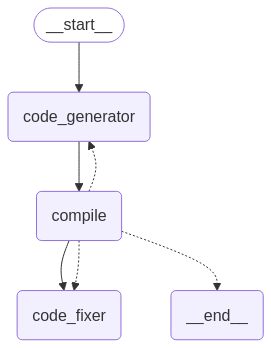

In [2]:
llmCodeAgent.pnggraph()

In [24]:
import json
jsontxt = """Warns that the specified signal comes from multiple `always` blocks,
each with different clocking. This warning does not look at individual
bits (see the example below).

This is considered bad style, as the consumer of a given signal may be
unaware of the inconsistent clocking, causing clock domain crossing or
timing bugs.

Faulty example:

```sv
always @(posedge clk) begin
  out2[7:0] <= d0;  // <--- Warning
end
always @(negedge clk) begin
  out2[15:8] <= d0;  // <--- Warning
end
```

Results in:

```
%Warning-MULTIDRIVEN: example.v:1:22 Signal has multiple driving blocks with different clocking: 'out2'
                      example.v:1:7 ... Location of first driving block
                      example.v:1:7 ... Location of other driving block
```

Ignoring this warning will only slow simulations; it will simulate
correctly. It may, however, cause longer simulation runtimes due to
reduced optimizations.
"""
a = {'txt': jsontxt}
json.dump(a, open('.ignore/tmp.txt', 'w+'))

In [13]:
import json
jsontxt = """A Warning that the specified signal is never used/consumed.
For example, you have a wire called `a`, declared as follows:

```sv
wire [3:0] a;
```

But in the operation of a module, you only use 2/4 bits of the wire `a`. For example:

```sv
assign a[1:0] = {1'b0, 1'b1};
```

And you forgot to use the `a[3:2]`. So, that is why this warning is raised.

You should fix this warning by removing unused signals in the declaration of a port, such as:

```sv
wire [1:0] a;
```

Or you can make use of the unused signals that you forgot:

```sv
assign a[3:0] = {1'b0, 1'b1, 1'b0, 1'b1};
```

"""
a = {'txt': jsontxt}
json.dump(a, open('.ignore/tmp.txt', 'w+'))

In [25]:
import ast
from scripts.lazy import readFileContent

verilator_warns = readFileContent("rag/verilator_warns.json")
verilator_warns: dict = ast.literal_eval(verilator_warns)

print(verilator_warns["WIDTHEXPAND"])

A more granular `WIDTH` warning, for
when a value is zero expanded.

Here is the description of `WIDTH` warning:

Warns that based on the width rules of Verilog:

-   Two operands have different widths, e.g., adding a 2-bit and 5-bit
    number.
-   A part select has a different size then needed to index into the
    packed or unpacked array, etc.

Verilator attempts to track the minimum width of unsized constants and
will suppress the warning when the minimum width is appropriate to fit
the required size.

Ignoring this warning will only suppress the lint check; it will
simulate correctly.

The recommendation is to fix these issues by:

-   Resize the variable or constant to match the needed size for the
    expression. E.g., `2'd2` instead of `3'd2`.
-   Using `'0` or `'1`, which automatically resize in an expression.
-   Using part selects to narrow a variable; e.g., `too_wide[1:0]`.
-   Using concatenate to widen a variable; e.g., `{1'b1, too_narrow}`.
-   Using cast to resize a va